# Direct exciton fraction in the cw driven XX–X cascade

This notebook analyzes steady-state emission in a resonantly driven biexciton–exciton cascade in a quantum dot under continuous-wave two-photon excitation (TPE).

The system is modeled as a four-level XX–X–G cascade using a Lindblad master equation implemented in QuTiP.

The main goal is to quantify unwanted direct exciton population under cw excitation. In the context of energy-time entanglement experiments based on the XX–X cascade, only photons emitted through the cascade XX → X → G contribute to the desired two-photon interference in a Franson interferometer. Additional exciton emission not originating from the cascade contributes an incoherent background in two-photon interference experiments and reduces the observable entanglement visibility.

To characterize this effect, the notebook evaluates the Direct Emission Fraction (DEF) as a measure of cascade purity and studies how it depends on excitation power as well as excitation and detection polarization.

The notebook focuses on:
- steady-state emission rates of the exciton (X) and biexciton (XX) transitions
- polarization dependence of excitation and detection
- suppression of direct exciton emission by suitable polarization configurations
- the power dependence of the DEF under cw resonant TPE

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from src.tpe_model import (
    ANGLES,
    DEFAULT_PARAMS,
    steady_state_density_matrix,
    exciton_emission_rate,
    biexciton_emission_rate,
    time_evolution,
    state_populations,
    populations_vs_time,
    system_frequencies,
    B,
)

# Model verification

Before analyzing polarization effects, we verify that the implemented model reproduces the expected physical behavior of the XX–X cascade.

## 1. Resonance condition and level structure

We first verify that the laser frequency fulfills the two-photon resonance condition with the biexciton state while remaining detuned from the single exciton transitions.

This ensures that the system operates in the intended two-photon excitation regime rather than resonantly driving the exciton transitions directly.

The ratio

2 ω_L / ω_B ≈ 1

confirms resonant two-photon excitation of the biexciton.

The detunings Δ_H and Δ_V quantify the off-resonant driving of the exciton transitions, while their difference corresponds to the fine structure splitting between the two exciton eigenstates.

In [6]:
params = DEFAULT_PARAMS

omega_H, omega_V, omega_B, omega_L = system_frequencies(params)

delta_H = omega_H - omega_L
delta_V = omega_V - omega_L

print("\nTwo photon resonance condition:")
print("2 * omega_L / omega_B =", 2 * omega_L / omega_B)

print("\nSingle photon detunings:")
print("delta_H =", delta_H)
print("delta_V =", delta_V)

print("\nSymmetry of fine structure splitting:")
print("delta_V - delta_H =", delta_V - delta_H)


Two photon resonance condition:
2 * omega_L / omega_B = 1.0

Single photon detunings:
delta_H = 2105.704682922922
delta_V = 2148.2441714666784

Symmetry of fine structure splitting:
delta_V - delta_H = 42.539488543756306


## 2. Radiative cascade dynamics without driving

As a second consistency check, we simulate the free radiative decay of the system without coherent driving (Ω = 0). The system is initialized in the biexciton state.

For a correct implementation of the decay channels, the following behavior is expected:

- the biexciton population decays exponentially with lifetime T1_XX
- the exciton populations rise transiently due to cascade feeding
- the ground state population approaches unity
- identical evolution of ρ_H and ρ_V confirms symmetric branching of the biexciton decay

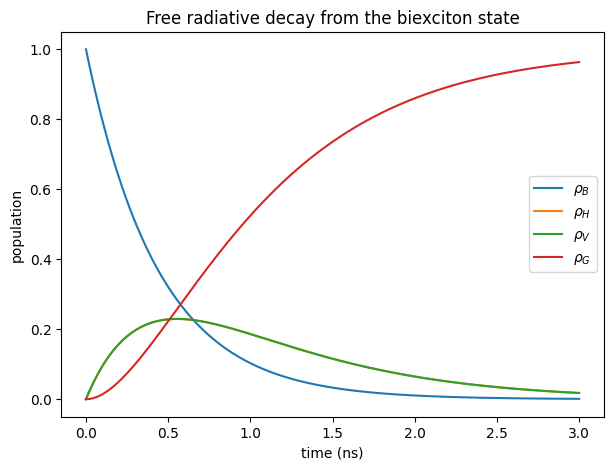

In [7]:
rho0 = B * B.dag()
tlist = np.linspace(0, 3, 400)

result = time_evolution(
    omega_drive=0.0,
    theta_exc=0.0,
    rho0=rho0,
    tlist=tlist,
    params=DEFAULT_PARAMS,
)

pops = populations_vs_time(result)

plt.figure(figsize=(7,5))
plt.plot(tlist, pops["B"], label=r"$\rho_B$")
plt.plot(tlist, pops["H"], label=r"$\rho_H$")
plt.plot(tlist, pops["V"], label=r"$\rho_V$")
plt.plot(tlist, pops["G"], label=r"$\rho_G$")
plt.xlabel("time (ns)")
plt.ylabel("population")
plt.title("Free radiative decay from the biexciton state")
plt.legend()
plt.show()

## 3. Steady state under continuous-wave excitation

We now verify that the driven open quantum system reaches physically meaningful steady states.

At low excitation strength, the system remains predominantly in the ground state. Increasing the drive populates the exciton and biexciton states via resonant two-photon excitation. At high excitation strength, populations approach stationary values determined by the balance between coherent driving and radiative decay.

The populations remain bounded between 0 and 1 and sum to unity for all excitation strengths, confirming a consistent implementation of the Hamiltonian and collapse operators.

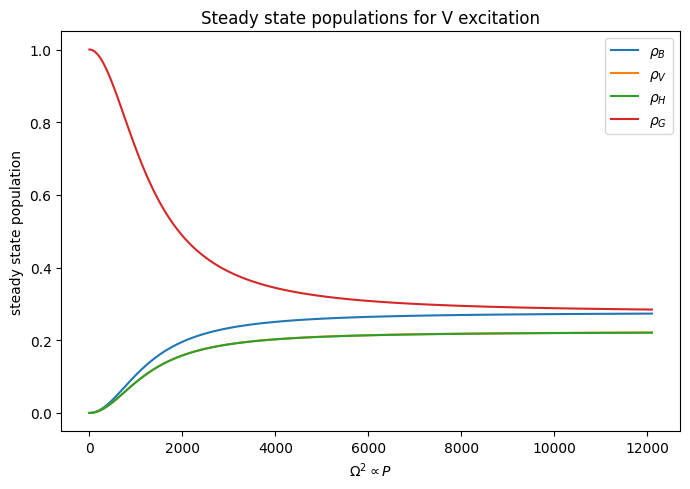

In [8]:
# excitation strength sweep
rabi_values = np.linspace(0, 110, 120)
rabi_squared = rabi_values**2

# choose one reference excitation polarization
theta_exc = ANGLES["V"]

pop_B = []
pop_V = []
pop_H = []
pop_G = []

for omega in rabi_values:

    rho_ss = steady_state_density_matrix(
        omega_drive=omega,
        theta_exc=theta_exc,
        params=DEFAULT_PARAMS,
    )

    pops = state_populations(rho_ss)

    pop_B.append(pops["B"])
    pop_V.append(pops["V"])
    pop_H.append(pops["H"])
    pop_G.append(pops["G"])

pop_B = np.array(pop_B)
pop_V = np.array(pop_V)
pop_H = np.array(pop_H)
pop_G = np.array(pop_G)

plt.figure(figsize=(7,5))

plt.plot(rabi_squared, pop_B, label=r"$\rho_B$")
plt.plot(rabi_squared, pop_V, label=r"$\rho_V$")
plt.plot(rabi_squared, pop_H, label=r"$\rho_H$")
plt.plot(rabi_squared, pop_G, label=r"$\rho_G$")

plt.xlabel(r"$\Omega^2 \propto P$")
plt.ylabel("steady state population")
plt.title("Steady state populations for V excitation")

plt.legend()
plt.tight_layout()
plt.show()

# Results: cascade emission under cw two-photon excitation

## 1. Power series in an orthogonal excitation–detection basis

We compute the emission rates of the exciton and biexciton transitions as a function of excitation strength for an orthogonal excitation–detection configuration. The excitation polarization is aligned with the V eigenstate of the fine structure splitting, while detection is performed in the orthogonal H basis.

This configuration corresponds to a common experimental scheme in resonance fluorescence experiments, where orthogonal polarizations suppress scattered laser light. Since H and V coincide with the eigenstates of the exciton Hamiltonian, this geometry minimizes polarization mixing and provides a well defined reference case.

In the weak driving regime, the biexciton emission exhibits the nonlinear scaling characteristic of resonant two-photon excitation. The exciton emission predominantly originates from the radiative cascade XX → X → G. At higher excitation strengths, both emission channels approach saturation due to the balance between coherent driving and radiative decay.

This configuration therefore defines a baseline case in which direct excitation of the exciton is strongly suppressed. It serves as a reference for identifying polarization configurations that introduce additional direct exciton contributions and reduce cascade purity.

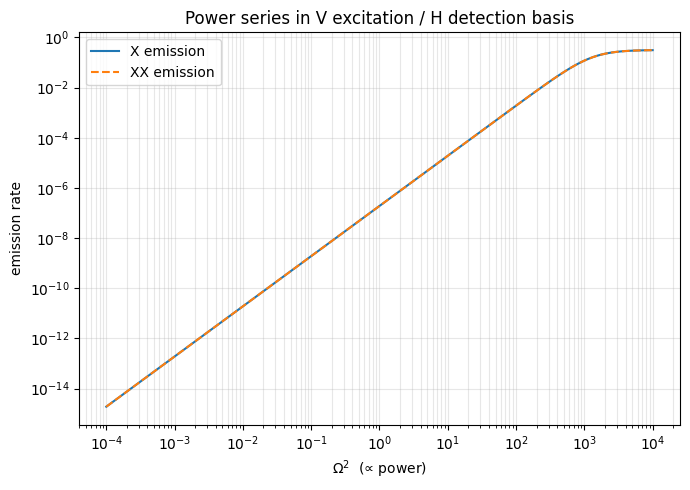

In [9]:
# excitation strength sweep
rabi_values = np.logspace(-2, 2, 120)
rabi_squared = rabi_values**2

# orthogonal eigenbasis configuration
theta_exc = ANGLES["V"]
theta_det = ANGLES["H"]

I_x = []
I_xx = []

for omega in rabi_values:

    rho_ss = steady_state_density_matrix(
        omega_drive=omega,
        theta_exc=theta_exc,
        params=DEFAULT_PARAMS,
    )

    I_x.append(
        exciton_emission_rate(
            rho_ss,
            theta_det=theta_det,
            params=DEFAULT_PARAMS,
        )
    )

    I_xx.append(
        biexciton_emission_rate(
            rho_ss,
            theta_det=theta_det,
            params=DEFAULT_PARAMS,
        )
    )

I_x = np.array(I_x)
I_xx = np.array(I_xx)

plt.figure(figsize=(7,5))

plt.loglog(rabi_squared, I_x, label="X emission")
plt.loglog(rabi_squared, I_xx,"--", label="XX emission")

plt.xlabel(r"$\Omega^2$  (∝ power)")
plt.ylabel("emission rate")
plt.title("Power series in V excitation / H detection basis")

plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Detection polarization dependence for fixed V excitation

Having established the orthogonal excitation–detection configuration as a reference case, we now examine how the detected emission depends on the choice of detection polarization for fixed V excitation.

This comparison is central for distinguishing cascade emission from direct exciton excitation contributions. In the orthogonal H detection basis, the detected exciton emission is predominantly fed by the radiative cascade XX → X → G. As the detection basis is rotated towards the excitation polarization V, the directly driven exciton state increasingly projects onto the detection channel, leading to an additional contribution to the detected X emission.

The biexciton emission, in contrast, is expected to remain much less sensitive to this change, since it reflects the population of the biexciton state rather than direct exciton excitation. Comparing both channels therefore provides the motivation for introducing the direct exciton fraction as a compact measure of cascade purity.

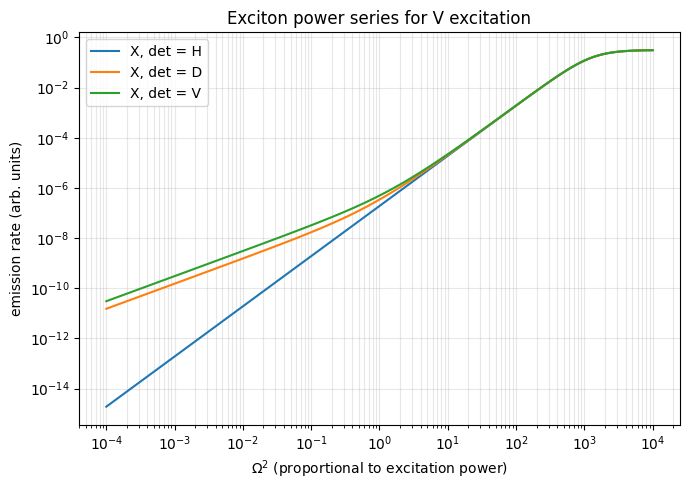

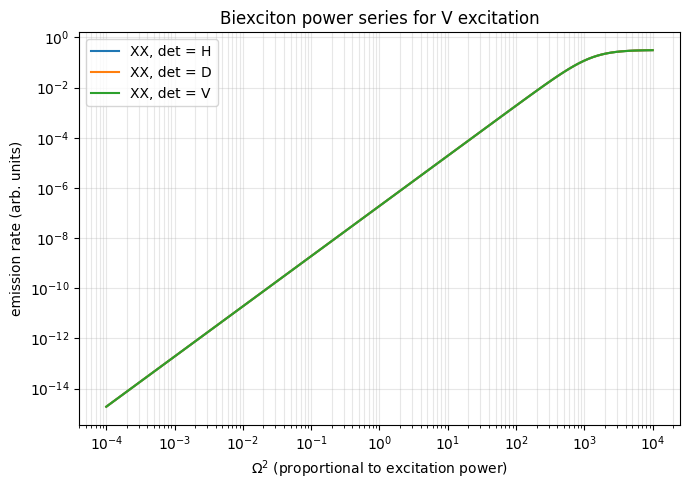

In [10]:
# excitation strength sweep
rabi_values = np.logspace(-2, 2, 120)
rabi_squared = rabi_values**2

# fixed excitation polarization
theta_exc = ANGLES["V"]

# detection configurations
det_configs = ["H", "D", "V"]

# compute steady states
rho_ss_list = []
for omega in rabi_values:
    rho_ss = steady_state_density_matrix(
        omega_drive=omega,
        theta_exc=theta_exc,
        params=DEFAULT_PARAMS,
    )
    rho_ss_list.append(rho_ss)

results = {}

for det_label in det_configs:
    theta_det = ANGLES[det_label]

    I_x = []
    I_xx = []

    for rho_ss in rho_ss_list:
        I_x.append(
            exciton_emission_rate(
                rho_ss,
                theta_det=theta_det,
                params=DEFAULT_PARAMS,
            )
        )

        I_xx.append(
            biexciton_emission_rate(
                rho_ss,
                theta_det=theta_det,
                params=DEFAULT_PARAMS,
            )
        )

    results[det_label] = {
        "I_x": np.array(I_x),
        "I_xx": np.array(I_xx),
    }

plt.figure(figsize=(7, 5))

for det_label in det_configs:
    plt.loglog(
        rabi_squared,
        results[det_label]["I_x"],
        label=f"X, det = {det_label}",
    )

plt.xlabel(r"$\Omega^2$ (proportional to excitation power)")
plt.ylabel("emission rate (arb. units)")
plt.title("Exciton power series for V excitation")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

for det_label in det_configs:
    plt.loglog(
        rabi_squared,
        results[det_label]["I_xx"],
        label=f"XX, det = {det_label}",
    )

plt.xlabel(r"$\Omega^2$ (proportional to excitation power)")
plt.ylabel("emission rate (arb. units)")
plt.title("Biexciton power series for V excitation")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Direct exciton fraction

To quantify the contribution of directly excited exciton emission in the detected X channel, we introduce the direct exciton fraction (DEF).

In the ideal cascade limit, every detected exciton photon originates from the radiative decay sequence

XX → X → G.

In this case, each biexciton emission event is followed by exactly one exciton emission event, such that the detected emission rates satisfy

I_X = I_XX.

Any excess exciton emission beyond the biexciton rate therefore indicates population of the exciton state that does not originate from the cascade, but instead from direct excitation processes.

We define the direct exciton fraction as the fraction of detected exciton emission that is not accounted for by the cascade channel,

DEF = (I_X - I_XX) / I_X.

DEF = 0 corresponds to a perfectly pure cascade, while DEF > 0 indicates admixture of directly excited exciton emission. The DEF therefore serves as a quantitative measure of cascade purity under continuous-wave two-photon excitation.

In [11]:
def direct_exciton_fraction(I_x, I_xx):
    """
    Direct exciton fraction (DEF).

    Measures the fraction of detected exciton emission that does not
    originate from the biexciton cascade.

    DEF = 0  -> ideal cascade
    DEF = 1  -> purely direct exciton emission
    """

    eps = 1e-15  # avoid division by zero at vanishing signal
    return np.clip((I_x - I_xx) / np.maximum(I_x, eps), 0.0, 1.0)

## Power dependence of the direct exciton fraction

We now evaluate the direct exciton fraction as a function of excitation power for different detection polarizations while keeping the excitation polarization fixed in the V eigenbasis.

In the orthogonal configuration (H detection), the detected exciton emission is predominantly fed by the radiative cascade XX → X → G, resulting in a DEF close to zero over the entire excitation range.

As the detection polarization is rotated towards the excitation basis, the directly driven exciton state acquires a finite projection onto the detection channel. This introduces an additional direct excitation pathway, leading to a finite DEF at low and intermediate excitation strengths.

With increasing excitation strength, the steady state is increasingly governed by the balance between coherent driving and radiative decay within the full cascade system. In this regime, the biexciton population becomes significant and the cascade contribution dominates the detected exciton emission. Consequently, the relative contribution of directly excited excitons decreases and the DEF approaches zero at high excitation power.

The observed behavior illustrates the transition from a polarization-sensitive excitation regime at weak driving to a cascade-dominated steady state at strong driving.

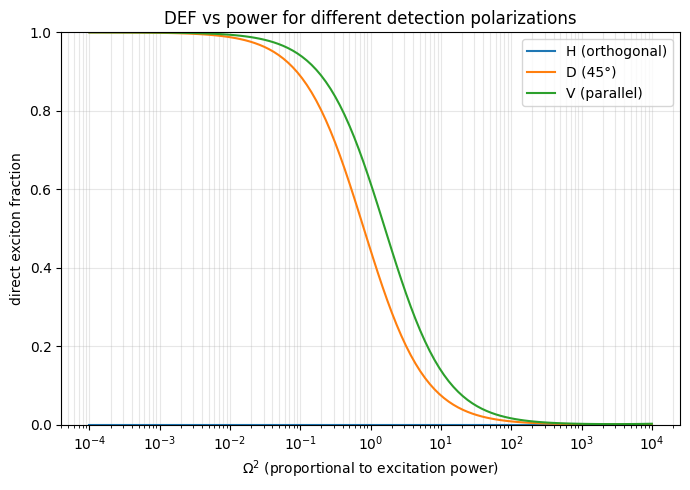

In [12]:
# excitation strength sweep
rabi_values = np.logspace(-2, 2, 120)
rabi_squared = rabi_values**2

theta_exc = ANGLES["V"]

det_configs = {
    "H (orthogonal)": ANGLES["H"],
    "D (45°)": ANGLES["D"],
    "V (parallel)": ANGLES["V"],
}

# steady states for all drive strengths
rho_ss_list = [
    steady_state_density_matrix(
        omega_drive=omega,
        theta_exc=theta_exc,
        params=DEFAULT_PARAMS,
    )
    for omega in rabi_values
]

plt.figure(figsize=(7,5))

for label, theta_det in det_configs.items():

    I_x  = np.array([
        exciton_emission_rate(rho, theta_det, DEFAULT_PARAMS)
        for rho in rho_ss_list
    ])

    I_xx = np.array([
        biexciton_emission_rate(rho, theta_det, DEFAULT_PARAMS)
        for rho in rho_ss_list
    ])

    DEF = direct_exciton_fraction(I_x, I_xx)

    plt.semilogx(rabi_squared, DEF, label=label)

plt.xlabel(r"$\Omega^2$ (proportional to excitation power)")
plt.ylabel("direct exciton fraction")
plt.title("DEF vs power for different detection polarizations")
plt.ylim(0,1)
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

## Polarization dependence of the direct exciton fraction

We now resolve the direct exciton fraction as a function of both excitation power and detection polarization angle for a fixed excitation in the V eigenbasis.

The DEF is minimized for orthogonal detection, where the directly driven exciton state has vanishing projection onto the detection basis and the detected exciton emission is dominated by the radiative cascade. As the detection polarization is rotated towards the excitation basis, the direct exciton contribution increasingly enters the detection channel, leading to a larger DEF.

With increasing excitation strength, the relative contribution of the cascade channel becomes dominant and the DEF decreases over the full polarization range. The map therefore visualizes the transition from a polarization sensitive regime at weak and intermediate driving to a cascade dominated regime at high excitation power.

Within the present model, this behavior is determined by the relative angle between excitation and detection polarization. The plot therefore illustrates how polarization filtering controls the direct exciton contribution under continuous-wave two-photon excitation.

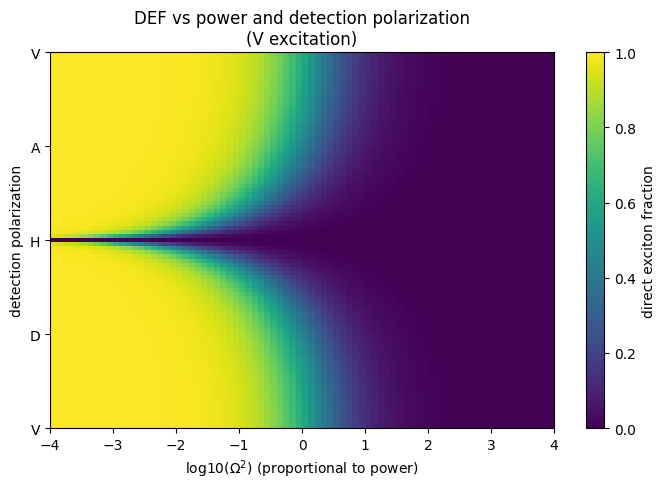

In [13]:
# power range
rabi_values = np.logspace(-2, 2, 80)
rabi_squared = rabi_values**2

# detection angles
theta_det_values = np.linspace(0, np.pi, 91)

# fixed excitation polarization
theta_exc = ANGLES["V"]

# compute steady states once
rho_ss_list = [
    steady_state_density_matrix(
        omega_drive=omega,
        theta_exc=theta_exc,
        params=DEFAULT_PARAMS,
    )
    for omega in rabi_values
]

# evaluate DEF on the 2D grid
DEF_map = np.zeros((len(theta_det_values), len(rabi_values)))

for j, rho_ss in enumerate(rho_ss_list):
    for i, theta_det in enumerate(theta_det_values):
        I_x = exciton_emission_rate(
            rho_ss,
            theta_det=theta_det,
            params=DEFAULT_PARAMS,
        )

        I_xx = biexciton_emission_rate(
            rho_ss,
            theta_det=theta_det,
            params=DEFAULT_PARAMS,
        )

        DEF_map[i, j] = direct_exciton_fraction(I_x, I_xx)

plt.figure(figsize=(7, 5))

im = plt.imshow(
    DEF_map,
    aspect="auto",
    origin="lower",
    extent=[
        np.log10(rabi_squared.min()),
        np.log10(rabi_squared.max()),
        0,
        180,
    ],
    vmin=0.0,
    vmax=1.0,
)

plt.colorbar(im, label="direct exciton fraction")
plt.xlabel(r"log10($\Omega^2$) (proportional to power)")
plt.ylabel("detection polarization")
plt.yticks([0, 45, 90, 135, 180], ["V", "D", "H", "A", "V"])
plt.title("DEF vs power and detection polarization\n(V excitation)")
plt.tight_layout()
plt.show()

## Excitation polarization dependence of the direct exciton fraction

We compare the direct exciton fraction for the four principal linear excitation bases V, D, H, and A. For each excitation polarization, the DEF is shown as a function of excitation power and detection polarization angle.

In all cases, the DEF is minimized when excitation and detection polarizations are orthogonal. In this configuration, the directly driven exciton state has minimal projection onto the detection basis, such that the detected exciton emission is predominantly fed by the radiative cascade XX → X → G.

Within the present model, decay rates and dephasing are assumed to be polarization independent. As a result, the DEF depends only on the relative angle between excitation and detection polarization, rather than on their orientation with respect to the intrinsic H/V eigenbasis. All excitation bases therefore exhibit qualitatively identical behavior, with the minimum DEF occurring at a relative angle of 90°.

The maps illustrate that polarization orthogonality is the key parameter controlling suppression of direct exciton emission under continuous-wave two-photon excitation.

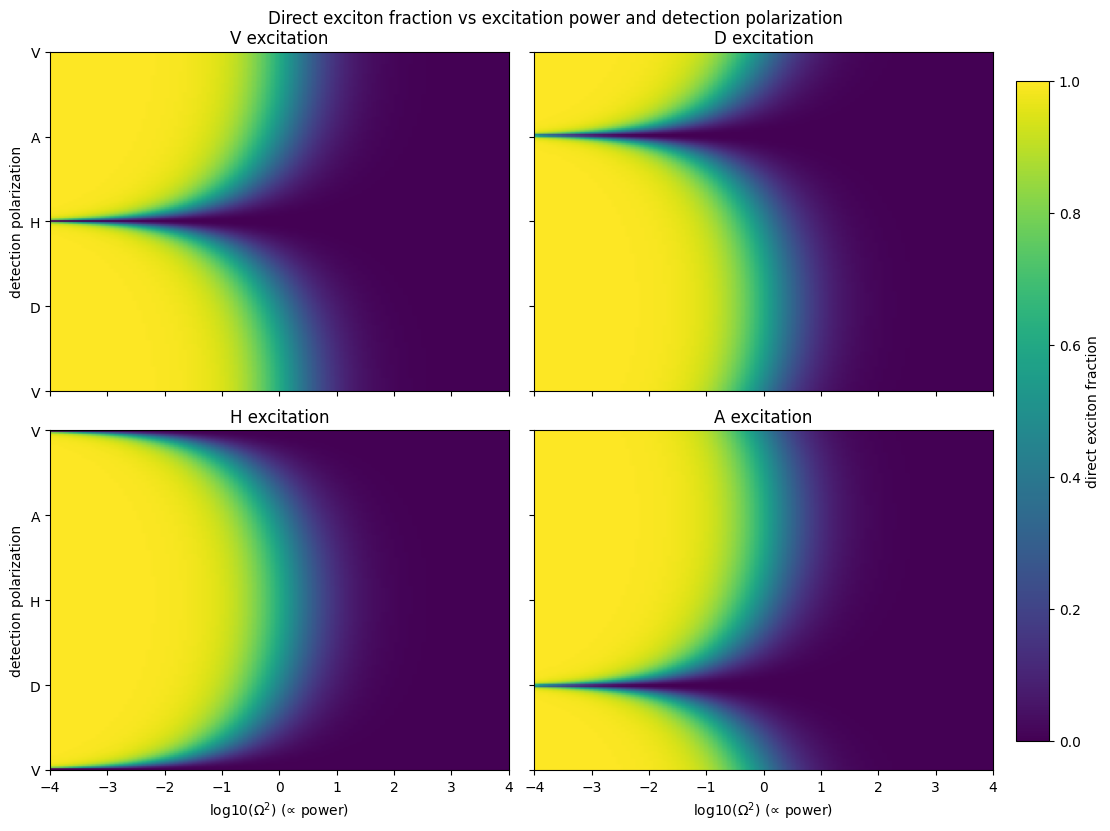

In [14]:
# parameter grids
rabi_values = np.logspace(-2, 2, 100)
rabi_squared = rabi_values**2

theta_det_values = np.linspace(0, np.pi, 181)

exc_configs = [
    ("V excitation", ANGLES["V"]),
    ("D excitation", ANGLES["D"]),
    ("H excitation", ANGLES["H"]),
    ("A excitation", ANGLES["A"]),
]

polarization_ticks = [0, 45, 90, 135, 180]
polarization_labels = ["V", "D", "H", "A", "V"]

# figure
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = axes.ravel()

for ax, (title, theta_exc) in zip(axes, exc_configs):

    # steady states for this excitation polarization
    rho_ss_list = [
        steady_state_density_matrix(
            omega_drive=omega,
            theta_exc=theta_exc,
            params=DEFAULT_PARAMS,
        )
        for omega in rabi_values
    ]

    DEF_map = np.zeros((len(theta_det_values), len(rabi_values)))

    for j, rho_ss in enumerate(rho_ss_list):
        for i, theta_det in enumerate(theta_det_values):

            I_x = exciton_emission_rate(
                rho_ss,
                theta_det=theta_det,
                params=DEFAULT_PARAMS,
            )

            I_xx = biexciton_emission_rate(
                rho_ss,
                theta_det=theta_det,
                params=DEFAULT_PARAMS,
            )

            DEF_map[i, j] = direct_exciton_fraction(I_x, I_xx)

    im = ax.imshow(
        DEF_map,
        aspect="auto",
        origin="lower",
        extent=[
            np.log10(rabi_squared.min()),
            np.log10(rabi_squared.max()),
            0,
            180,
        ],
        vmin=0,
        vmax=1,
    )

    ax.set_title(title)
    ax.set_yticks(polarization_ticks)
    ax.set_yticklabels(polarization_labels)

# axis labels
axes[0].set_ylabel("detection polarization")
axes[2].set_ylabel("detection polarization")

for ax in axes[2:]:
    ax.set_xlabel(r"log10($\Omega^2$) (∝ power)")

# colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    fraction=0.035,
    pad=0.02,
)
cbar.set_label("direct exciton fraction")

fig.suptitle(
    "Direct exciton fraction vs excitation power and detection polarization",
    y=1.02,
)

plt.show()

## Conclusion

The simulations show that the direct exciton fraction in cw two-photon excitation is primarily controlled by the relative angle between excitation and detection polarization.

Orthogonal polarization suppresses direct exciton contributions and maximizes cascade purity. At high excitation strengths, the cascade channel dominates for all polarization configurations.

The presented framework provides a compact way to quantify cascade purity and can be extended to include additional effects such as polarization-dependent dephasing or asymmetric decay rates.